In [4]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os

In [5]:
import json
from pprint import pprint

path = r'jobs\20251022_171601\exp-fc1-minmax-ep10000-bs2048-lr1e-3-s42-h512-256-128'
path = r'jobs\20251110_122808\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128'

metrics_path = path + r'\metrics.json'

with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics_data = json.load(f)

pprint(metrics_data.keys())

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])


In [6]:
metrics_data['dataset_meta']

{'environment_config': {'num_modes': 25,
  'pixel_resolution': 64,
  'oversizing_factor': 1,
  'num_airy': 5,
  'coronagraph_charge': 6,
  'ppsr': 2},
 'dataset_config': {'N': 100000,
  'delta_t': 0.001,
  'noise_enabled': False,
  'dm_random_noise': 1e-07,
  'nudge_amplitude': 3e-07,
  'nudge_mode_index': 0,
  'save_checkpoints': None},
 'nudge_vector': [3e-07,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'num_samples': 100000,
 'image_triplet_description': '(baseline, +nudge, -nudge)'}

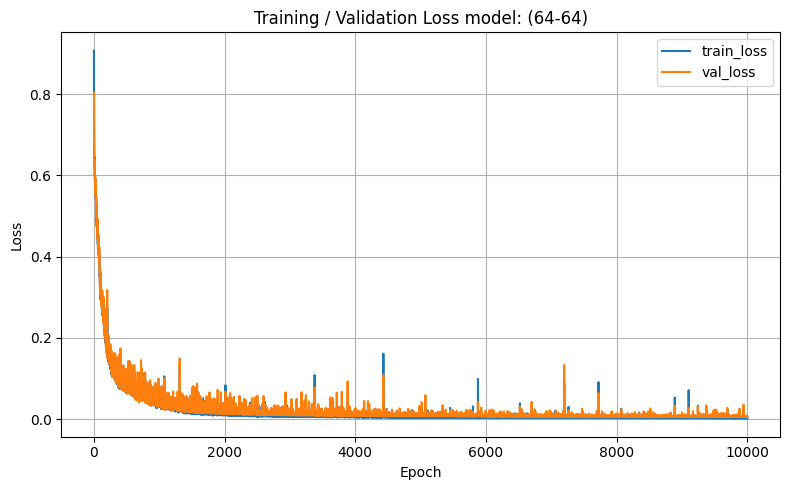

In [7]:
history = metrics_data['history']
train = history.get('train_loss', [])
val = history.get('val_loss', [])

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train)+1), train, label='train_loss')
if val:
    plt.plot(range(1, len(val)+1), val, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss model: (64-64)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
import glob
import numpy as np

# search for .pth/.pt files in the experiment directory (uses existing `path` variable)
candidates = glob.glob(os.path.join(path, '*.pth')) + glob.glob(os.path.join(path, '*.pt'))
if not candidates:
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(('.pth', '.pt')):
                candidates.append(os.path.join(root, f))

if not candidates:
    raise FileNotFoundError(f'No .pth/.pt files found under {path!r}')

checkpoint_path = max(candidates, key=os.path.getmtime)


In [9]:
metrics_data['y_norm']

{'mean': -2.08677190111084e-11, 'std': 1.9999989220309544e-08}

In [10]:
metrics_data.keys()

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])

In [11]:
metrics_data['dataset_meta']

{'environment_config': {'num_modes': 25,
  'pixel_resolution': 64,
  'oversizing_factor': 1,
  'num_airy': 5,
  'coronagraph_charge': 6,
  'ppsr': 2},
 'dataset_config': {'N': 100000,
  'delta_t': 0.001,
  'noise_enabled': False,
  'dm_random_noise': 1e-07,
  'nudge_amplitude': 3e-07,
  'nudge_mode_index': 0,
  'save_checkpoints': None},
 'nudge_vector': [3e-07,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0],
 'num_samples': 100000,
 'image_triplet_description': '(baseline, +nudge, -nudge)'}

In [12]:
metrics_data['input_shape']

[20, 20, 3]

In [13]:
from archs.fc1 import FC1
import torch

model = FC1(
    final_output_dim=metrics_data['output_dim'], 
    image_input_shape=metrics_data['input_shape'], 
    hidden_layers=metrics_data['args']['fc1_hidden'], 
    activation=metrics_data['args']['fc1_activation'],
    final_activation=metrics_data['args']['fc1_final_activation']    
    )
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

FC1(
  (final_net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1200, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=128, out_features=25, bias=True)
    (8): LeakyReLU(negative_slope=0.01)
  )
)

In [45]:
from environment import CoronagraphEnvironment

env_config = metrics_data['dataset_meta']['environment_config']
if 'pixel_resolution' in env_config:
    env_config['pixels'] = env_config.pop('pixel_resolution')
if 'ppsr' in env_config:
    env_config['pixels_per_spacial_res'] = env_config.pop('ppsr')

env = CoronagraphEnvironment(**env_config, num_noise_modes=500)

initializing coronagraph env. might take a minute.


In [34]:
import pickle
from pathlib import Path

dataset_path = Path(r'data\dataset100S25M.pkl')
if not dataset_path.exists():
    raise FileNotFoundError(f"{dataset_path} not found")

with dataset_path.open('rb') as f:
    dataset = pickle.load(f)

print("Loaded:", dataset_path)
print("Type:", type(dataset))

if isinstance(dataset, dict):
    print("Keys:", list(dataset.keys()))
elif isinstance(dataset, (list, tuple)):
    print("Length:", len(dataset))
else:
    try:
        arr = np.asarray(dataset)  # np imported in another cell
        print("As numpy array shape:", arr.shape)
    except Exception:
        pass

# show a small preview without dumping everything
if isinstance(dataset, dict):
    for k in list(dataset.keys())[:10]:
        v = dataset[k]
        if isinstance(v, (list, tuple)):
            print(f"{k}: list len={len(v)}")
        else:
            print(f"{k}: type={type(v)}")
elif isinstance(dataset, (list, tuple)) and len(dataset):
    print("First element type:", type(dataset[0]))
    try:
        preview = dataset[0]
        if isinstance(preview, (list, tuple, dict, np.ndarray)):
            print("Preview (first element):", (preview if isinstance(preview, dict) else (np.asarray(preview).shape if hasattr(preview, '__len__') else type(preview))))
        else:
            print("Preview (first element):", preview)
    except Exception:
        pass

Loaded: data\dataset100S25M.pkl
Type: <class 'dict'>
Keys: ['dm_settings', 'images', 'meta']
dm_settings: list len=100
images: list len=100
meta: type=<class 'dict'>


In [35]:
pprint(dataset['meta'])
env_config

{'dataset_config': {'N': 100,
                    'delta_t': 0.001,
                    'dm_random_noise': 1e-07,
                    'noise_enabled': False,
                    'nudge_amplitude': 3e-07,
                    'nudge_mode_index': 0,
                    'save_checkpoints': None},
 'environment_config': {'coronagraph_charge': 6,
                        'num_airy': 5,
                        'num_modes': 25,
                        'oversizing_factor': 1,
                        'pixel_resolution': 64,
                        'ppsr': 2},
 'image_triplet_description': '(baseline, +nudge, -nudge)',
 'nudge_vector': array([3.e-07, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00]),
 'num_samples': 100}


{'num_modes': 25,
 'oversizing_factor': 1,
 'num_airy': 5,
 'coronagraph_charge': 6,
 'pixels': 64,
 'pixels_per_spacial_res': 2}

In [36]:
# from train_job import NORMALIZERS

# nudge_vec = metrics_data['dataset_meta']['nudge_vector']
# delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
# dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
# N = 1
# TEST_INDEX = 1

# x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
# params = metrics_data['x_norm'].copy()
# params.pop('type')

# y_mean = metrics_data['y_norm']['mean']
# y_std = metrics_data['y_norm']['std']

# for _ in range(N):
#         # env.deformable_mirror.flatten()
#         # env.set_random_dm(noise=dm_random_noise)
#         # original = env.deformable_mirror.actuators.copy()
#         original = dataset['dm_settings'][TEST_INDEX]

#         original_contrast = env.get_contrast(delta_t=1e15)

#         img1 = new_imgs[TEST_INDEX][0]

#         # img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

#         env.deformable_mirror.flatten()
#         env.deformable_mirror.actuators = original + nudge_vec
#         img2 = new_imgs[TEST_INDEX][1]

#         # img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

#         env.deformable_mirror.flatten()
#         env.deformable_mirror.actuators = original - nudge_vec
#         img3 = new_imgs[TEST_INDEX][2]
#         # img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
#         with torch.no_grad():
#             imgs = np.array([img1, img2, img3])
#             imgs = torch.asarray(imgs, dtype=torch.float).unsqueeze(0)
            
#             imgs_norm, _ = x_norm_func(imgs, **params)
#             imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
#             print(f"imgs_norm.shape = {imgs_norm.shape}")
#             y_pred = model(imgs_norm)

#             print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

#             y_pred *= y_std
#             y_pred -= y_mean

#             print(y_pred)
#             print(original)

        
#         env.deformable_mirror.flatten()
#         env.deformable_mirror.actuators = original - np.array(y_pred[0])
#         new_contrast = env.get_contrast(delta_t=1e15)

#         img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
#         plt.imshow(img1, cmap='inferno')
#         plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
#         plt.colorbar()
#         plt.show()

#         plt.imshow(img4, cmap='inferno')
#         plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
#         plt.colorbar()
#         plt.show()



imgs_norm.shape = torch.Size([1, 20, 20, 3])
MSE: 1.4740426888419975
tensor([[-6.2048e-09, -1.7337e-08, -1.2629e-08, -3.8880e-09,  5.8436e-09,
         -4.5139e-09, -1.0912e-08,  6.6340e-09, -7.9877e-12, -5.9336e-09,
          8.1891e-09, -9.2583e-09,  3.5149e-09,  5.1536e-09, -7.4785e-09,
         -8.2604e-10,  1.3090e-08, -1.2211e-10, -4.8402e-09, -2.3368e-09,
         -1.4213e-09,  4.9226e-10,  3.0378e-13, -6.2137e-09,  4.0035e-09]])
[-2.36907359e-09  5.72393411e-09  2.05581528e-09  1.71234041e-09
  4.17066746e-09 -3.99826187e-09 -1.06838583e-08  3.66482833e-09
  3.27518977e-09 -5.40984393e-09  6.53929503e-09 -9.43350160e-09
  4.56246070e-10  2.75718762e-09 -7.69815665e-09 -8.00895749e-10
  9.51164100e-09 -8.32936020e-11 -5.00098449e-09 -2.26413953e-09
 -7.15883008e-10  2.65202279e-09  3.27496704e-09 -5.84548708e-09
  2.44827504e-09]


C:\Users\alexe\AppData\Local\Temp\ipykernel_1560\3612305595.py:42: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_1560\3612305595.py:52: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


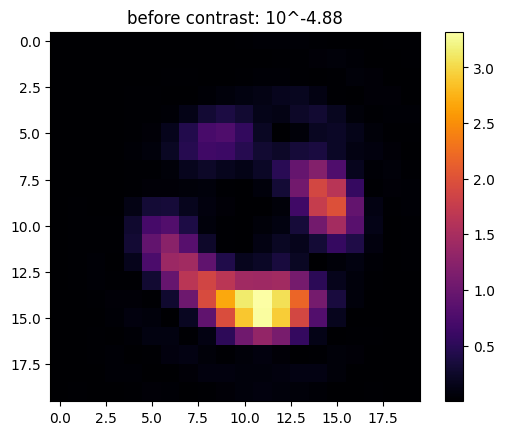

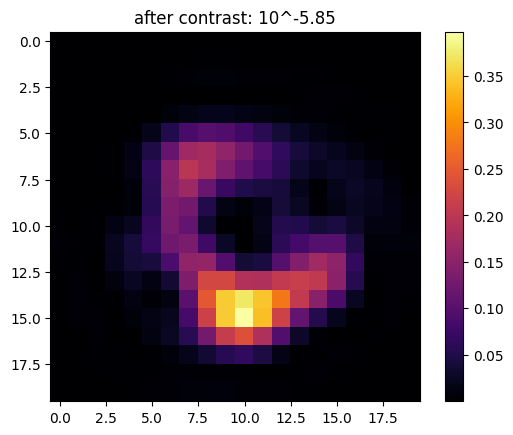

In [37]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        env.deformable_mirror.flatten()
        env.noise_gen_mirror.flatten()
        env.set_random_dm(noise=2.5e-8)
        original = env.deformable_mirror.actuators.copy()

        original_contrast = env.get_contrast(delta_t=1e15)

        img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original + nudge_vec
        img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - nudge_vec
        img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

        img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        plt.imshow(img1, cmap='inferno')
        plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
        plt.colorbar()
        plt.show()

        plt.imshow(img4, cmap='inferno')
        plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
        plt.colorbar()
        plt.show()



imgs_norm.shape = torch.Size([1, 20, 20, 3])
MSE: 7.4045929331908775
tensor([[ 9.8136e-08, -2.4257e-10, -5.8824e-10, -1.2426e-10,  5.0798e-08,
          1.2127e-08, -7.4725e-10, -1.0989e-08,  4.7661e-09, -7.4843e-08,
         -2.0388e-08,  5.3404e-09,  1.7630e-08, -1.6813e-08, -1.7065e-08,
         -4.1441e-08, -1.1797e-09, -2.8521e-09, -1.3802e-08,  9.3704e-09,
          1.3690e-08,  6.4449e-09,  1.9362e-09, -1.6138e-08,  9.7057e-12]])
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


C:\Users\alexe\AppData\Local\Temp\ipykernel_1560\2193778530.py:42: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_1560\2193778530.py:52: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


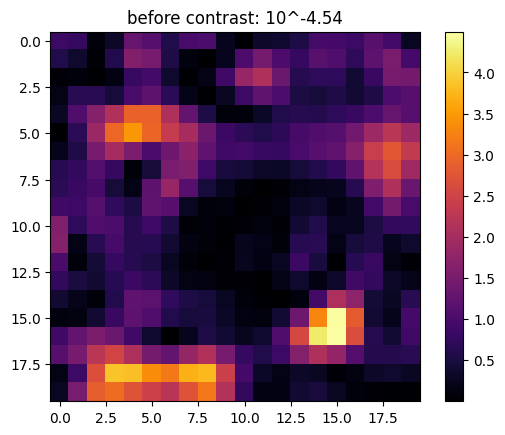

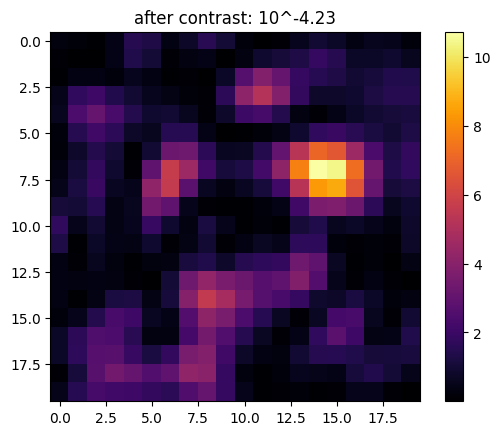

In [54]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        env.deformable_mirror.flatten()
        env.noise_gen_mirror.flatten()
        env.set_random_noise_dm(noise=1e-7)
        original = env.deformable_mirror.actuators.copy()

        original_contrast = env.get_contrast(delta_t=1e15)

        img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original + nudge_vec
        img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - nudge_vec
        img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

        img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        plt.imshow(img1, cmap='inferno')
        plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
        plt.colorbar()
        plt.show()

        plt.imshow(img4, cmap='inferno')
        plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
        plt.colorbar()
        plt.show()

